<a href="https://colab.research.google.com/github/niranjanaapp/diabetes-prediction/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (3).csv


In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [44]:
data = pd.read_csv("diabetes (3).csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Prediction
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,0
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,0
4,0,137,40,35,168,43.1,2.288,33,1,1
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0
764,2,122,70,27,0,36.8,0.340,27,0,0
765,5,121,72,23,112,26.2,0.245,30,0,0
766,1,126,60,0,0,30.1,0.349,47,1,0


In [45]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]


In [46]:
df.columns = df.columns.str.strip()
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)


In [47]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
data[cols] = data[cols].replace(0, np.nan)
data.fillna(data.median(), inplace=True)


In [48]:
print(data.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


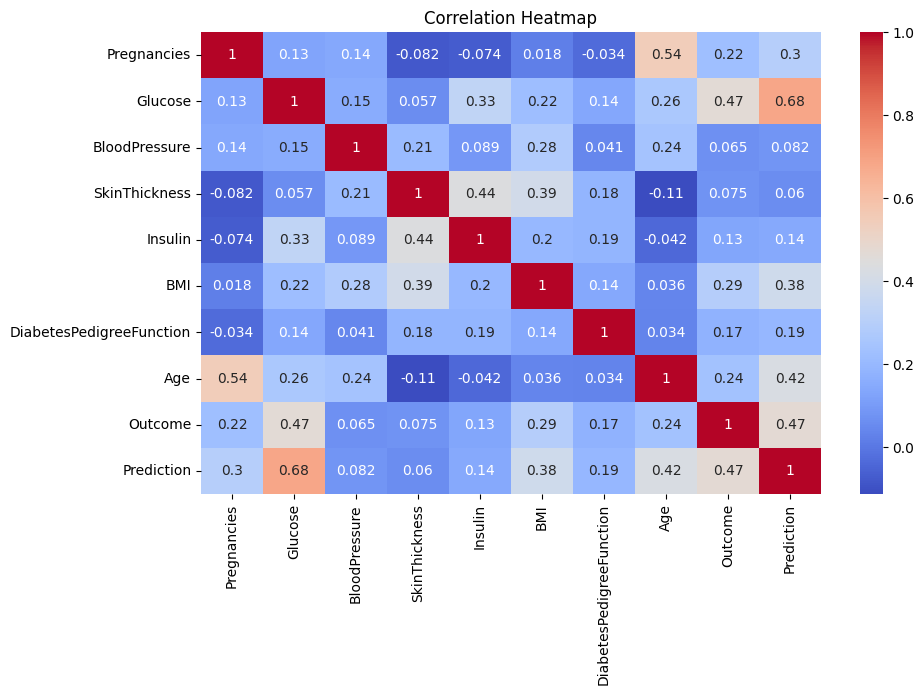

In [49]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [50]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]


In [51]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


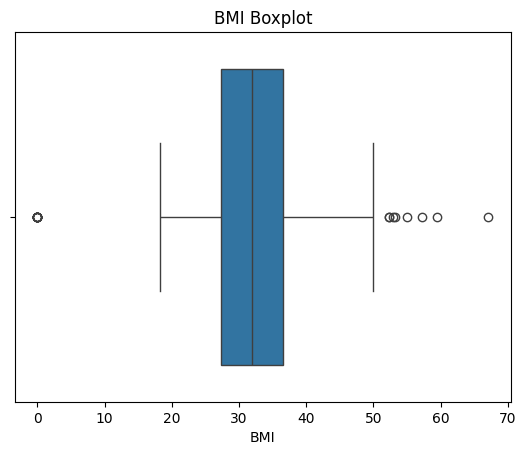

In [52]:
sns.boxplot(x=df['BMI'])
plt.title("BMI Boxplot")
plt.show()

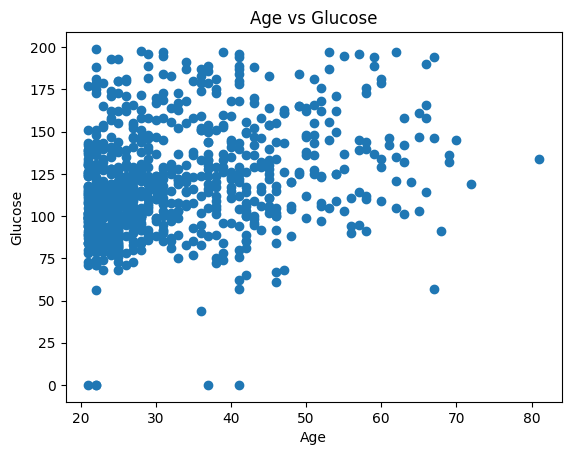

In [53]:
plt.scatter(df['Age'], df['Glucose'])
plt.title("Age vs Glucose")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.show()


In [54]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [56]:
param_grid = {
    'C':[0.01,0.1,1,10],
    'solver':['liblinear','lbfgs'],
    'max_iter':[100,200,500]
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)

model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}


In [57]:
y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7532467532467533


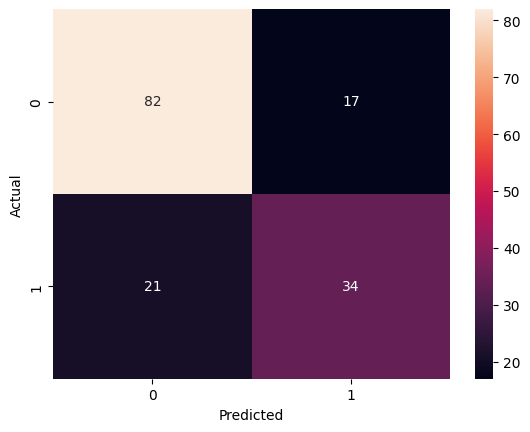

In [59]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [60]:
scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())


Cross Validation Scores: [0.75974026 0.74025974 0.78571429 0.79738562 0.77124183]
Average Score: 0.7708683473389355


In [61]:
df['Prediction'] = model.predict(X)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Prediction
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,0
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,0
4,0,137,40,35,168,43.1,2.288,33,1,1
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0
764,2,122,70,27,0,36.8,0.340,27,0,0
765,5,121,72,23,112,26.2,0.245,30,0,0
766,1,126,60,0,0,30.1,0.349,47,1,0


In [62]:
diabetes = (df['Prediction'] == 1).sum()
no_diabetes = (df['Prediction'] == 0).sum()

print("Diabetes:", diabetes)
print("No Diabetes:", no_diabetes)


Diabetes: 218
No Diabetes: 550


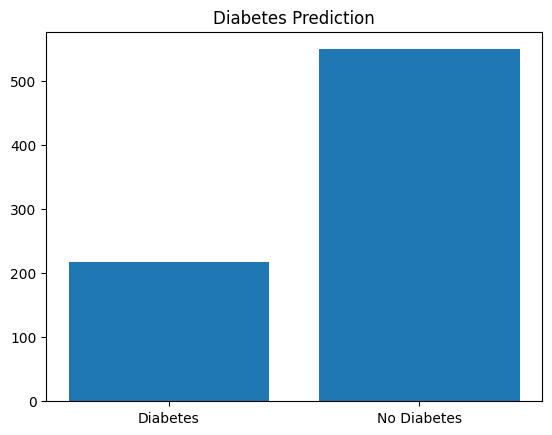

In [63]:
plt.bar(['Diabetes', 'No Diabetes'], [diabetes, no_diabetes])
plt.title("Diabetes Prediction")
plt.show()
